In [1]:
pip install scikit-fem matplotlib numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.5 MB/s eta 0:00:00


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skfem import *
from skfem.helpers import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
from scipy.interpolate import griddata
import torch.nn.functional as F
import random
import os
import math
#  Repro
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

#  數據生成部分

class GaussianMixture2D:
    """生成2D高斯混合函數"""
    def __init__(self, n_gaussians=5, radius=1.0):
        self.n_gaussians = n_gaussians
        self.radius = radius
        self.params = self._generate_params()

    def _generate_params(self):
        """在圓內隨機生成高斯參數"""
        params = {
            'amplitudes': np.random.uniform(-2.0, 2.0, self.n_gaussians),
            'centers': [],
            'sigmas': np.random.uniform(0.05, 0.2, self.n_gaussians) * self.radius
        }
        for _ in range(self.n_gaussians):
            r = np.random.uniform(0, 0.6 * self.radius)
            theta = np.random.uniform(0, 2 * np.pi)
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            params['centers'].append([x, y])
        params['centers'] = np.array(params['centers'])
        return params

    def evaluate(self, x, y):
        """計算f(x,y)"""
        result = np.zeros_like(x)
        for i in range(self.n_gaussians):
            a_i = self.params['amplitudes'][i]
            c_i = self.params['centers'][i]
            sigma_i = self.params['sigmas'][i]
            dist_sq = (x - c_i[0])**2 + (y - c_i[1])**2
            result += a_i * np.exp(-dist_sq / (2 * sigma_i**2))
        return result

class CircularPoissonFEMSolver:
    """圓形域上的Poisson方程FEM求解器"""
    def __init__(self, radius=1.0, n_refine=6):
        self.radius = radius
        m = MeshTri.init_circle(nrefs=n_refine)
        self.mesh = MeshTri(m.p * radius, m.t)
        self.basis = Basis(self.mesh, ElementTriP1())

    def solve(self, f_func):
        """求解 -Δu = f on circular domain with u=0 on boundary"""
        @BilinearForm
        def laplacian(u, v, _):
            return dot(grad(u), grad(v))

        @LinearForm
        def rhs(v, w):
            x, y = w.x
            f_values = f_func(x, y)
            return f_values * v

        K = laplacian.assemble(self.basis)
        f = rhs.assemble(self.basis)

        # 穩健邊界 DOFs
        try:
            D = self.basis.get_dofs(self.mesh.boundary_facets())
        except Exception:
            D = self.basis.get_dofs()

        u_fem = solve(*condense(K, f, D=D))
        return u_fem

    def interpolate_to_grid(self, u_fem, nx=64, ny=64):
        """將FEM解插值到規則網格；linear→nearest 補洞；圓外設 0。"""
        x = np.linspace(-self.radius, self.radius, nx)
        y = np.linspace(-self.radius, self.radius, ny)
        X, Y = np.meshgrid(x, y)

        fem_points = self.mesh.p.T
        pts_grid = np.column_stack([X.ravel(), Y.ravel()])

        u_lin = griddata(fem_points, np.asarray(u_fem), pts_grid, method='linear')
        u_lin = u_lin.reshape(ny, nx)

        if np.isnan(u_lin).any():
            u_nn = griddata(fem_points, np.asarray(u_fem), pts_grid, method='nearest')
            u_nn = u_nn.reshape(ny, nx)
            nan_mask = np.isnan(u_lin)
            u_lin[nan_mask] = u_nn[nan_mask]

        outside = (X**2 + Y**2) > (self.radius**2)
        u_lin[outside] = 0.0
        return u_lin.astype(np.float32), X, Y

class CircularDatasetGenerator:
    """生成圓形域數據集"""
    def __init__(self, n_samples=1000, radius=1.0, nx=64, ny=64, n_gaussians_range=(3, 8)):
        self.n_samples = n_samples
        self.radius = radius
        self.nx = nx
        self.ny = ny
        self.n_gaussians_range = n_gaussians_range
        self.solver = CircularPoissonFEMSolver(radius=radius, n_refine=6)

    def generate_dataset(self):
        dataset = {'f': [], 'u': [], 'params': [], 'mask': None}
        print(f"Generating {self.n_samples} samples on circular domain...")

        x = np.linspace(-self.radius, self.radius, self.nx)
        y = np.linspace(-self.radius, self.radius, self.ny)
        X, Y = np.meshgrid(x, y)
        mask = X**2 + Y**2 <= self.radius**2
        dataset['mask'] = mask

        for i in range(self.n_samples):
            if (i + 1) % 100 == 0:
                print(f"  Progress: {i+1}/{self.n_samples}")

            n_gaussians = np.random.randint(*self.n_gaussians_range)
            gm = GaussianMixture2D(n_gaussians=n_gaussians, radius=self.radius)

            def f_func(xq, yq):
                return gm.evaluate(xq, yq)

            u_fem = self.solver.solve(f_func)
            u_grid, X, Y = self.solver.interpolate_to_grid(u_fem, self.nx, self.ny)
            f_grid = gm.evaluate(X, Y).astype(np.float32)
            f_grid[~mask] = 0

            dataset['f'].append(f_grid)
            dataset['u'].append(u_grid)
            dataset['params'].append(gm.params)

        dataset['f'] = np.array(dataset['f'])
        dataset['u'] = np.array(dataset['u'])
        print("Dataset generation complete!")
        return dataset

    def save_dataset(self, dataset, filename='circular_poisson_dataset.npz'):
        np.savez_compressed(filename, f=dataset['f'], u=dataset['u'], mask=dataset['mask'])
        with open(filename.replace('.npz', '_params.pkl'), 'wb') as file:
            pickle.dump(dataset['params'], file)
        print(f"Dataset saved to {filename}")

Loading Dataset

📁 File: circular_poisson_dataset.npz
Keys in dataset: ['f', 'u', 'mask']

📊 Data Shapes:
  f (input):  (1000, 64, 64)
  u (output): (1000, 64, 64)
  mask:       (64, 64)

📈 Data Statistics:
  f - min: -4.5377, max: 4.2744, mean: -0.0002
  u - min: -0.2280, max: 0.2496, mean: -0.0001
  mask - coverage: 75.59%

🔧 Parameters:
  Number of samples: 1000
  Example parameters for sample 0:
    Number of Gaussians: 6
    Amplitudes: [ 1.80285723  0.92797577  0.39463394 -1.37592544 -1.37602192 -1.76766555]
    Sigmas: [0.17992642 0.14016725 0.15621089 0.05308767 0.19548648 0.1748664 ]

🎨 Visualizing 3 random samples...


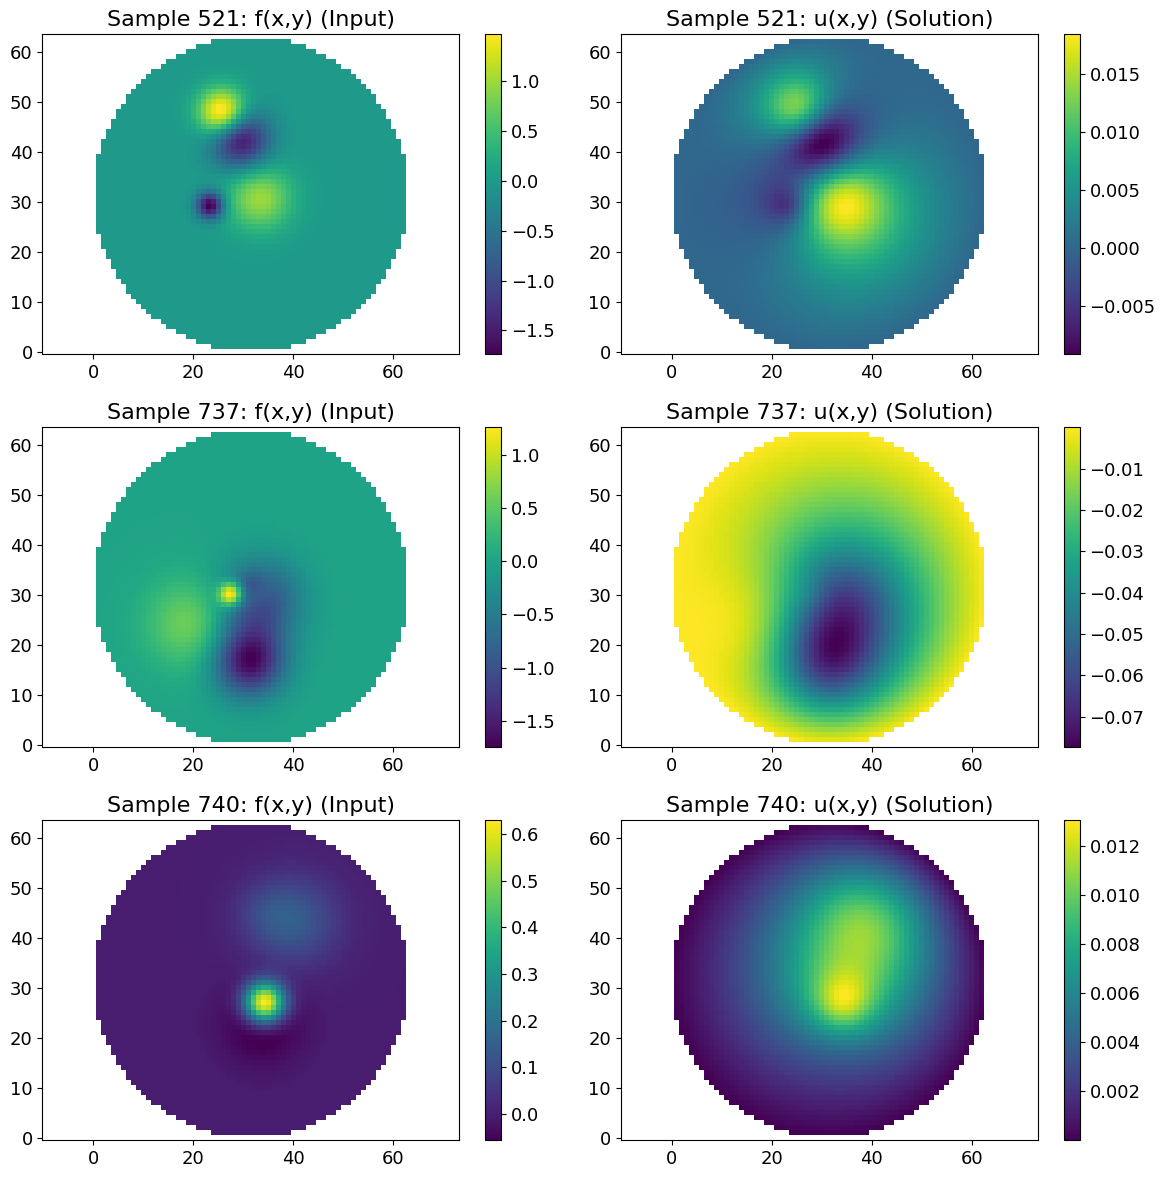

✓ Visualization saved to dataset_visualization.png

Extracting Specific Samples
Extracted 100 samples
Subset shapes: f=(100, 64, 64), u=(100, 64, 64)

Accessing Individual Samples

Sample 0:
  f shape: (64, 64)
  u shape: (64, 64)
  f range: [-2.3261, 0.8928]
  u range: [-0.0548, 0.0019]

Data Slicing Examples

Dataset split:
  Training:   800 samples
  Validation: 100 samples
  Test:       100 samples

Converting to PyTorch (optional)
✓ Converted to PyTorch tensors:
  f: torch.Size([1000, 64, 64]), dtype: torch.float32
  u: torch.Size([1000, 64, 64]), dtype: torch.float32
  mask: torch.Size([64, 64]), dtype: torch.float32

✓ All done!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

def load_and_inspect_dataset(npz_file='circular_poisson_dataset.npz',
                             params_file='circular_poisson_dataset_params.pkl'):
    """讀取並檢查數據集"""

    print("="*60)
    print("Loading Dataset")
    print("="*60)

    # 讀取 .npz 文件
    data = np.load(npz_file)

    print(f"\n📁 File: {npz_file}")
    print(f"Keys in dataset: {data.files}")

    # 讀取數據
    f = data['f']
    u = data['u']
    mask = data['mask']

    print(f"\n📊 Data Shapes:")
    print(f"  f (input):  {f.shape}")
    print(f"  u (output): {u.shape}")
    print(f"  mask:       {mask.shape}")

    print(f"\n📈 Data Statistics:")
    print(f"  f - min: {f.min():.4f}, max: {f.max():.4f}, mean: {f.mean():.4f}")
    print(f"  u - min: {u.min():.4f}, max: {u.max():.4f}, mean: {u.mean():.4f}")
    print(f"  mask - coverage: {mask.sum() / mask.size * 100:.2f}%")

    # 讀取參數
    try:
        with open(params_file, 'rb') as file:
            params = pickle.load(file)
        print(f"\n🔧 Parameters:")
        print(f"  Number of samples: {len(params)}")
        print(f"  Example parameters for sample 0:")
        print(f"    Number of Gaussians: {len(params[0]['amplitudes'])}")
        print(f"    Amplitudes: {params[0]['amplitudes']}")
        print(f"    Sigmas: {params[0]['sigmas']}")
    except FileNotFoundError:
        print(f"\n⚠️  Parameters file not found: {params_file}")
        params = None

    return f, u, mask, params

def visualize_samples(f, u, mask, n_samples=10):
    """可視化幾個樣本"""

    print(f"\n🎨 Visualizing {n_samples} random samples...")

    # 隨機選擇樣本
    indices = np.random.choice(len(f), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i, idx in enumerate(indices):
        # 應用 mask
        f_masked = f[idx].copy()
        u_masked = u[idx].copy()
        f_masked[~mask] = np.nan
        u_masked[~mask] = np.nan

        # f(x,y) - 輸入
        im0 = axes[i, 0].imshow(f_masked, cmap='viridis', origin='lower')
        axes[i, 0].set_title(f'Sample {idx}: f(x,y) (Input)')
        axes[i, 0].axis('equal')
        plt.colorbar(im0, ax=axes[i, 0])

        # u(x,y) - 輸出 (FEM 解)
        im1 = axes[i, 1].imshow(u_masked, cmap='viridis', origin='lower')
        axes[i, 1].set_title(f'Sample {idx}: u(x,y) (Solution)')
        axes[i, 1].axis('equal')
        plt.colorbar(im1, ax=axes[i, 1])

        # # Mask
        # axes[i, 2].imshow(mask, cmap='gray', origin='lower')
        # axes[i, 2].set_title('Circular Domain Mask')
        # axes[i, 2].axis('equal')

    plt.tight_layout()
    plt.savefig('dataset_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Visualization saved to dataset_visualization.png")

def extract_subset(f, u, mask, indices):
    """提取數據子集"""
    return f[indices], u[indices], mask

def save_subset(f_subset, u_subset, mask, filename='subset.npz'):
    """保存數據子集"""
    np.savez_compressed(filename, f=f_subset, u=u_subset, mask=mask)
    print(f"✓ Subset saved to {filename}")

#  使用範例

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



plt.rcParams.update({
    "font.size": 14,        # 全部字體基準（ticks/labels/legend）
    "axes.titlesize": 16,   # title
    "axes.labelsize": 15,   # x/y label
    "xtick.labelsize": 13,  # x ticks
    "ytick.labelsize": 13,  # y ticks
    "legend.fontsize": 13,  # legend
})



if __name__ == "__main__":

    # 1. 讀取數據
    f, u, mask, params = load_and_inspect_dataset()

    # 2. 可視化一些樣本
    visualize_samples(f, u, mask, n_samples=3)

    # 3. 提取特定樣本
    print("\n" + "="*60)
    print("Extracting Specific Samples")
    print("="*60)

    # 例如:提取前 100 個樣本
    indices = range(100)
    f_subset, u_subset, _ = extract_subset(f, u, mask, indices)
    print(f"Extracted {len(indices)} samples")
    print(f"Subset shapes: f={f_subset.shape}, u={u_subset.shape}")

    # 4. 保存子集 (可選)
    # save_subset(f_subset, u_subset, mask, 'subset_100.npz')

    # 5. 訪問單個樣本
    print("\n" + "="*60)
    print("Accessing Individual Samples")
    print("="*60)

    sample_idx = 0
    print(f"\nSample {sample_idx}:")
    print(f"  f shape: {f[sample_idx].shape}")
    print(f"  u shape: {u[sample_idx].shape}")
    print(f"  f range: [{f[sample_idx].min():.4f}, {f[sample_idx].max():.4f}]")
    print(f"  u range: [{u[sample_idx].min():.4f}, {u[sample_idx].max():.4f}]")

    # 6. 數據切片示例
    print("\n" + "="*60)
    print("Data Slicing Examples")
    print("="*60)

    # 訓練集 / 驗證集 / 測試集劃分
    n_total = len(f)
    n_train = int(0.8 * n_total)
    n_val = int(0.1 * n_total)

    f_train = f[:n_train]
    u_train = u[:n_train]

    f_val = f[n_train:n_train+n_val]
    u_val = u[n_train:n_train+n_val]

    f_test = f[n_train+n_val:]
    u_test = u[n_train+n_val:]

    print(f"\nDataset split:")
    print(f"  Training:   {len(f_train)} samples")
    print(f"  Validation: {len(f_val)} samples")
    print(f"  Test:       {len(f_test)} samples")

    # 7. 使用 PyTorch
    print("\n" + "="*60)
    print("Converting to PyTorch")
    print("="*60)

    try:
        import torch

        f_torch = torch.FloatTensor(f)
        u_torch = torch.FloatTensor(u)
        mask_torch = torch.FloatTensor(mask)

        print(f"✓ Converted to PyTorch tensors:")
        print(f"  f: {f_torch.shape}, dtype: {f_torch.dtype}")
        print(f"  u: {u_torch.shape}, dtype: {u_torch.dtype}")
        print(f"  mask: {mask_torch.shape}, dtype: {mask_torch.dtype}")

    except ImportError:
        print("⚠️  PyTorch not installed, skipping conversion")

    print("\n" + "="*60)
    print("✓ All done!")
    print("="*60)